In [1]:
import sys, json, os
sys.path.append("..")
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from src.explain import explain

pipe = joblib.load("../models/final_xgb_pipeline.joblib")
X_test = pd.read_parquet("../data/processed/X_test.parquet")
tp_df = pd.read_parquet("../data/processed/test_predictions.parquet")
final = json.load(open("../reports/final_features.json"))["final"]
t = json.load(open("../reports/final_decision.json"))["flag_threshold"]

rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), 20000, replace=False)
Xs = X_test.iloc[idx]
ys = tp_df["y"].values[idx]
ps = tp_df["p"].values[idx]

In [2]:
agg, base, margin = explain(pipe, Xs, final)
err = np.abs(agg.sum(axis=1).values + base - margin).max()
print("additivity check (should be ~0):", err)
assert err < 1e-3

additivity check (should be ~0): 1.001358e-05


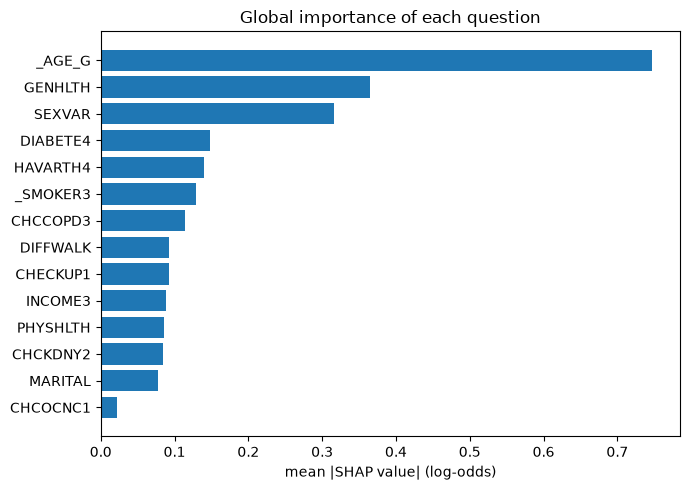

_AGE_G      0.299
GENHLTH     0.146
SEXVAR      0.126
DIABETE4    0.059
HAVARTH4    0.056
_SMOKER3    0.052
CHCCOPD3    0.046
DIFFWALK    0.037
CHECKUP1    0.037
INCOME3     0.035
PHYSHLTH    0.034
CHCKDNY2    0.034
MARITAL     0.031
CHCOCNC1    0.009
dtype: float32


In [3]:
imp = agg.abs().mean().sort_values()
plt.figure(figsize=(7, 5))
plt.barh(imp.index, imp.values)
plt.xlabel("mean |SHAP value| (log-odds)")
plt.title("Global importance of each question")
plt.tight_layout()
plt.savefig("../reports/figures/16_shap_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print((imp / imp.sum()).sort_values(ascending=False).round(3))

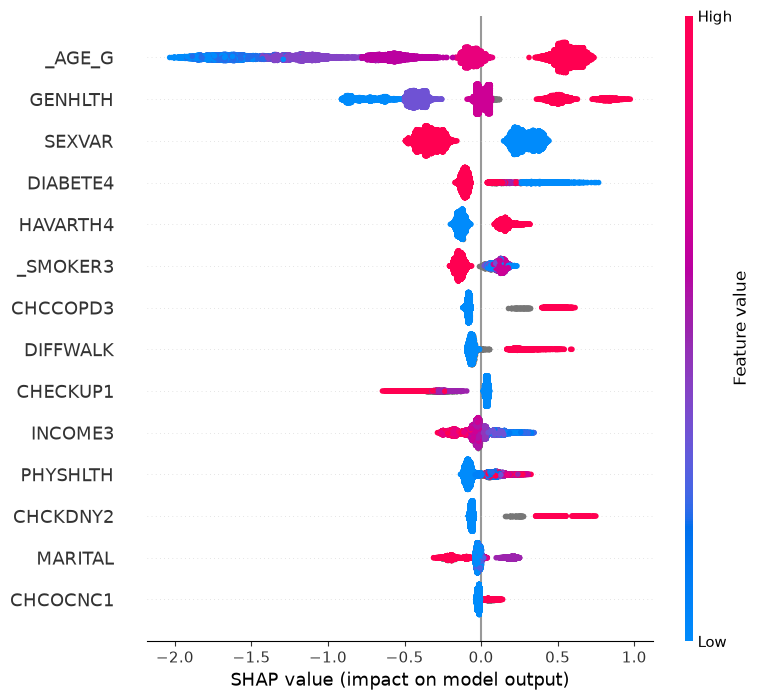

In [4]:
shap.summary_plot(agg.values, Xs[final], feature_names=final, show=False, max_display=14)
plt.savefig("../reports/figures/17_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

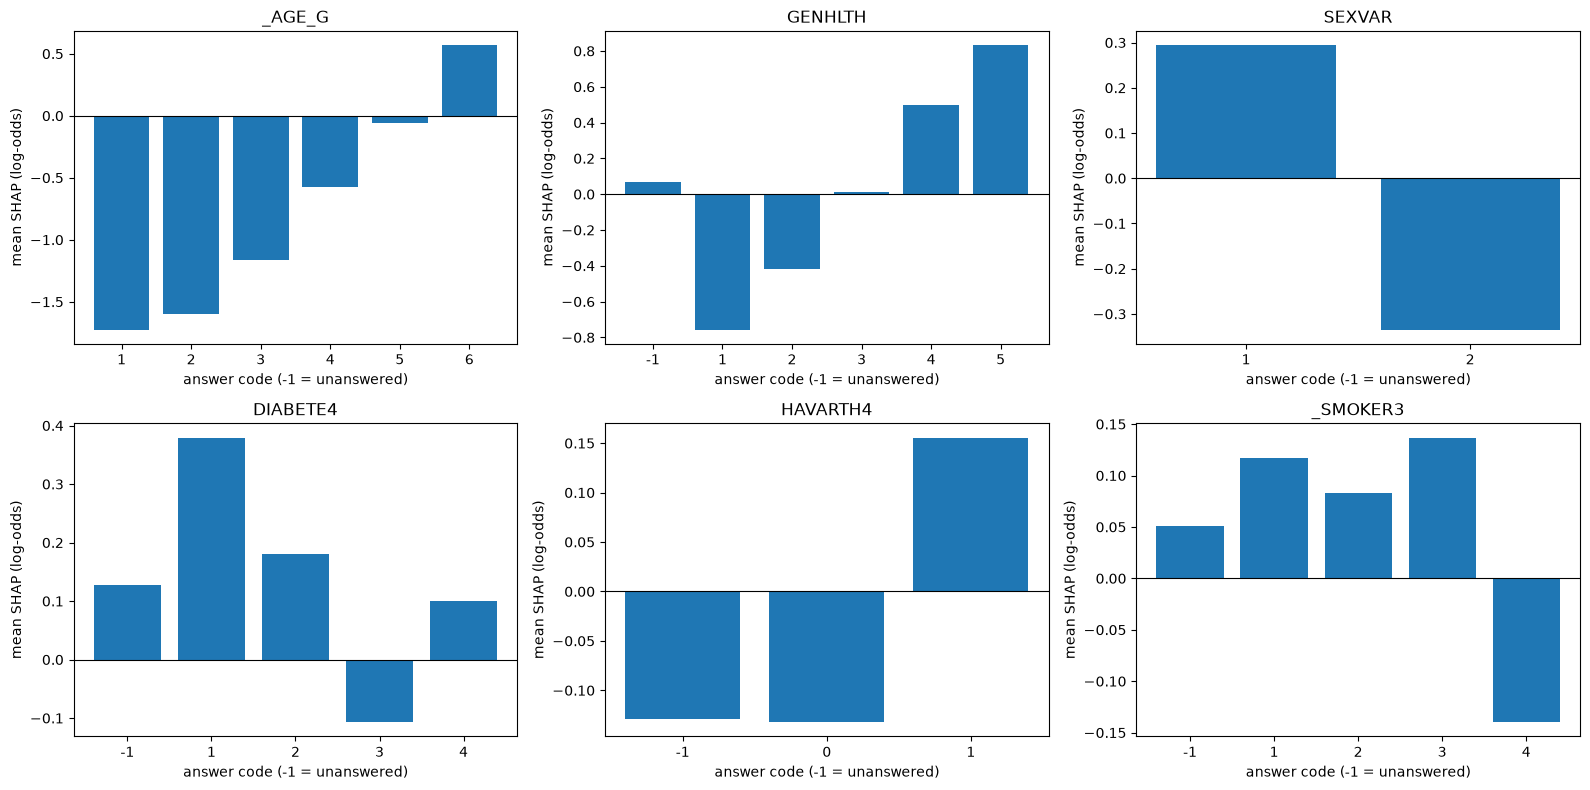

_AGE_G odds multiplier by answer: {1.0: 0.18000000715255737, 2.0: 0.20000000298023224, 3.0: 0.3100000023841858, 4.0: 0.5600000023841858, 5.0: 0.9399999976158142, 6.0: 1.7699999809265137}
GENHLTH odds multiplier by answer: {1.0: 0.4699999988079071, 2.0: 0.6600000262260437, 3.0: 1.0099999904632568, 4.0: 1.649999976158142, 5.0: 2.299999952316284}
SEXVAR odds multiplier by answer: {1.0: 1.340000033378601, 2.0: 0.7200000286102295}


In [5]:
top6 = imp.sort_values(ascending=False).index[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), top6):
    key = Xs[col].fillna(-1)
    eff = agg[col].groupby(key).mean()
    ax.bar([str(int(v)) if float(v).is_integer() else f"{v:.1f}" for v in eff.index], eff.values)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(col)
    ax.set_xlabel("answer code (-1 = unanswered)")
    ax.set_ylabel("mean SHAP (log-odds)")
plt.tight_layout()
plt.savefig("../reports/figures/18_shap_answer_effects.png", dpi=300, bbox_inches="tight")
plt.show()

for col in ["_AGE_G", "GENHLTH", "SEXVAR"]:
    eff = agg[col].groupby(Xs[col]).mean()
    print(col, "odds multiplier by answer:", np.exp(eff).round(2).to_dict())

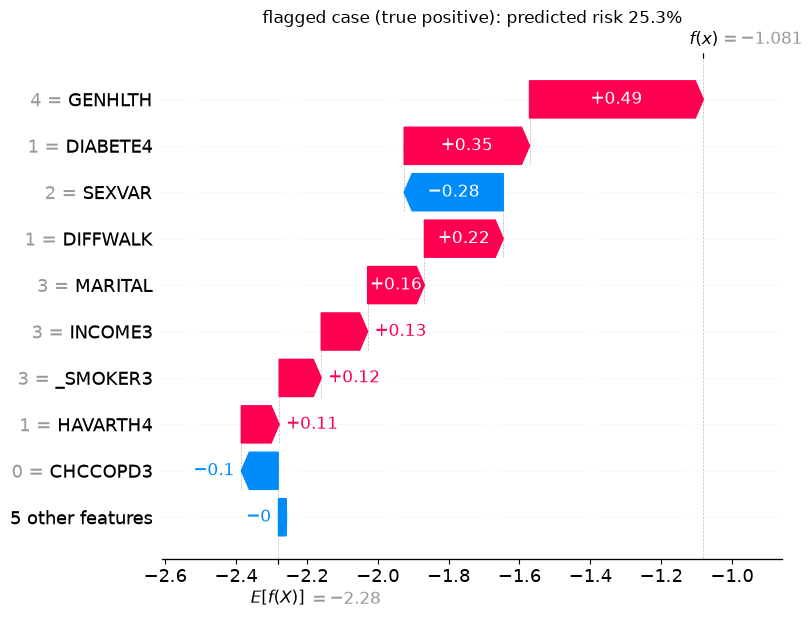

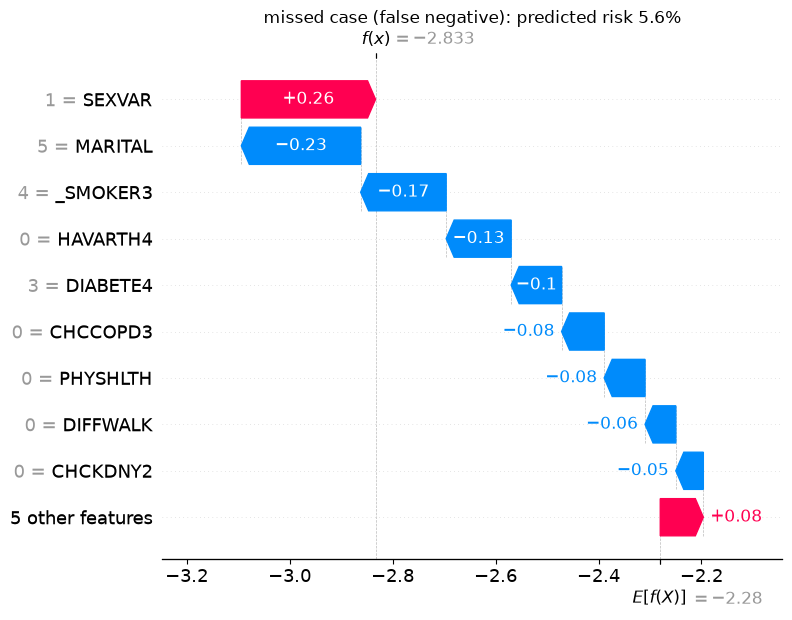

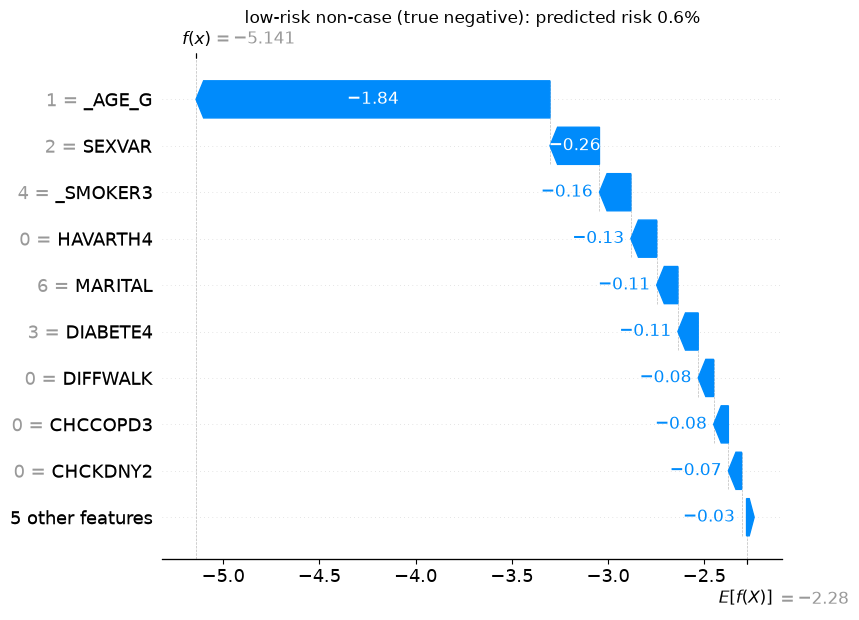

In [6]:
cases = np.where(ys == 1)[0]
non = np.where(ys == 0)[0]

flagged = cases[ps[cases] >= t]
missed = cases[ps[cases] < t]
i_tp = flagged[np.argsort(ps[flagged])[len(flagged) // 2]]     # a typical flagged case
i_fn = missed[np.argsort(ps[missed])[len(missed) // 2]]        # a typical missed case
i_tn = non[np.argsort(ps[non])[len(non) // 10]]                # a low-risk non-case

picks = [("flagged case (true positive)", i_tp),
         ("missed case (false negative)", i_fn),
         ("low-risk non-case (true negative)", i_tn)]
for k, (name, i) in enumerate(picks, 1):
    e = shap.Explanation(values=agg.iloc[i].values, base_values=base,
                         data=Xs.iloc[i][final].values, feature_names=final)
    shap.plots.waterfall(e, show=False)
    plt.title(f"{name}: predicted risk {ps[i]:.1%}")
    plt.savefig(f"../reports/figures/19_shap_local_{k}.png", dpi=300, bbox_inches="tight")
    plt.show()

## SHAP findings

SHAP values (TreeExplainer, log-odds units) were computed on a 20,000-row random sample of the test set and summed from the model's encoded columns back onto the 14 original questions; contributions plus the base value reproduce the model output (max error 1e-5).

**Global importance.** Age group (29.9% of total mean |SHAP|), general health (14.6%) and sex (12.6%) account for 57% of the model's attribution, followed by diabetes (5.9%), arthritis (5.6%), smoking (5.2%) and COPD (4.6%). The top three match the question knock-out test; arthritis and smoking rank higher by SHAP than by knock-out (≈ 0.0015 ROC-AUC lost), indicating that their information is largely recoverable from other answers.

**Effects.** Relative to the baseline, the odds multiplier rises from 0.18 (ages 18–24) to 1.77 (65+), roughly a 10-fold difference attributable to age itself; poor vs excellent general health differs about 4.9-fold (2.30 vs 0.47); male vs female about 1.9-fold (1.34 vs 0.72). Diabetes (+0.38 log-odds) and arthritis (+0.16) raise risk; never smoking (−0.14) lowers it.

**Individual explanations.** A flagged case (25.3%) was driven by fair general health, diabetes and difficulty walking, offset by female sex; a missed case (5.6%) had low-risk answers on almost every question (never-smoker, no listed conditions, no walking difficulty), consistent with the model lacking blood pressure and cholesterol information; a low-risk non-case (0.6%) was dominated by age 18–24 (−1.84 of a total −2.86 shift from baseline).

**Limitations.** SHAP describes what the model learned, not causal effects; marital status and income contribute as proxies for age and socioeconomic circumstances.